Plot successfully saved to Figure_1e.pdf.


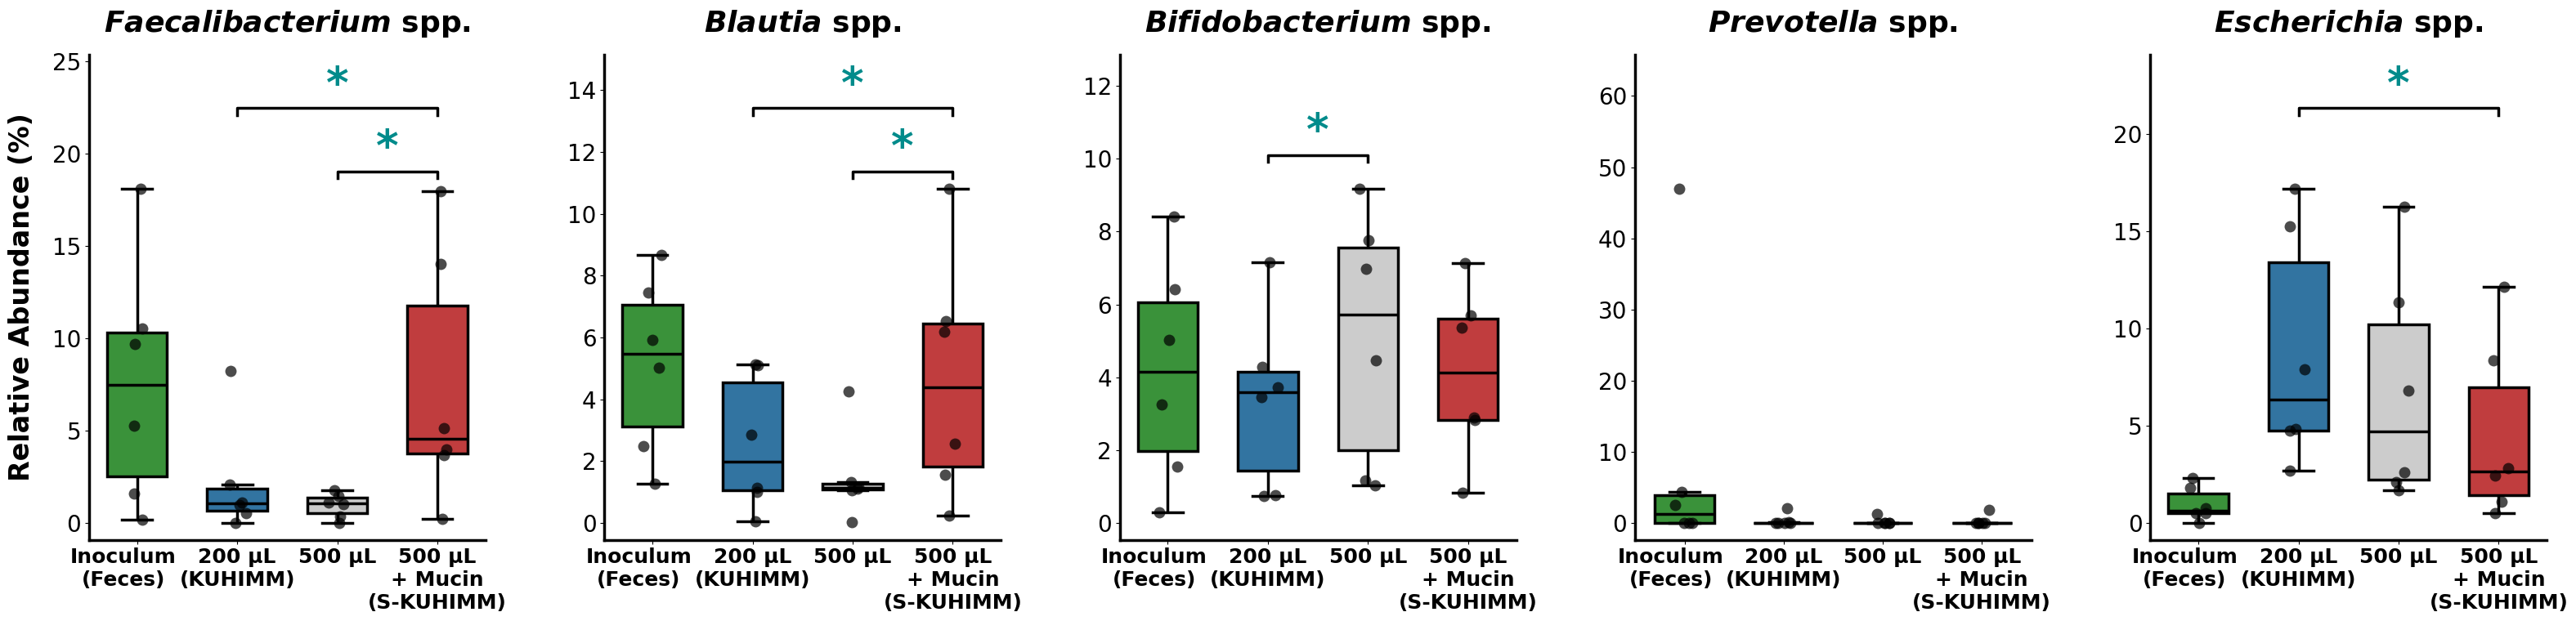

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.transforms as mtransforms
from scipy.stats import wilcoxon
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# =============================================================================
# Global Plotting Configuration (Strict Nature Standards)
# =============================================================================
plt.rcParams.update({
    'font.size': 20,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'sans-serif'],
    'pdf.fonttype': 42,
    'axes.linewidth': 2.5,
    'mathtext.default': 'regular'
})

# Universal Settings for Significance Markers
STAR_COLOR = '#008B8B'  # Dark Turquoise
STAR_SIZE = 38

def annotate_p(ax, x1, x2, y, h, p_val):
    """Adds a strict, professional statistical bracket with a turquoise asterisk."""
    if p_val < 0.05:
        ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=2.5, c='k')
        ax.text((x1+x2)*0.5, y+h + h*0.2, '*', ha='center', va='bottom',
                color=STAR_COLOR, fontsize=STAR_SIZE, fontweight='bold')

# =============================================================================
# 1. Load Data & Strategy B Classification (Focus on 72h)
# =============================================================================
df = pd.read_csv('(1d)_500muc_16S_Genus_level.csv')
bac_cols = [c for c in df.columns if c.startswith('d__Bacteria')]

def classify_conditions(c):
    """Extract Inoculum and 72h Strategy B components."""
    if 'FEC' in c:
        return 'Inoculum'
    if '72h' not in c:
        return None

    is_mucin = any(m in c for m in ['MUC', '0.8gMUC', '08MUC'])
    if '200' in c:
        return 'KUHIMM (200µL)'
    elif '500' in c:
        return 'S-KUHIMM (500µL+Mucin)' if is_mucin else 'KUHIMM (500µL)'
    return None

df['Group'] = df['Condition'].apply(classify_conditions)
df['Donor'] = df['Condition'].str.extract(r'^(HS-[^-]+|[^0-9-]+)')
df['Total_Bac'] = df[bac_cols].sum(axis=1)

# =============================================================================
# 2. Extract Relative Abundances of Target Guilds
# =============================================================================
df['Faecalibacterium'] = df[[c for c in bac_cols if 'Faecalibacterium' in c]].sum(axis=1) / df['Total_Bac'] * 100
df['Blautia'] = df[[c for c in bac_cols if 'Blautia' in c]].sum(axis=1) / df['Total_Bac'] * 100
df['Bifidobacterium'] = df[[c for c in bac_cols if 'Bifidobacterium' in c]].sum(axis=1) / df['Total_Bac'] * 100
df['Prevotella'] = df[[c for c in bac_cols if 'f__Prevotellaceae' in c]].sum(axis=1) / df['Total_Bac'] * 100
df['Escherichia'] = df[[c for c in bac_cols if 'Escherichia' in c]].sum(axis=1) / df['Total_Bac'] * 100

plot_df = df.dropna(subset=['Group']).copy()
agg_cols = ['Faecalibacterium', 'Blautia', 'Bifidobacterium', 'Prevotella', 'Escherichia']
plot_df = plot_df.groupby(['Donor', 'Group'])[agg_cols].mean().reset_index()

# =============================================================================
# 3. Plotting Configuration
# =============================================================================
x_order = ['Inoculum', 'KUHIMM (200µL)', 'KUHIMM (500µL)', 'S-KUHIMM (500µL+Mucin)']
palette = {
    'Inoculum': '#2ca02c',
    'KUHIMM (200µL)': '#1f77b4',
    'KUHIMM (500µL)': '#CCCCCC',
    'S-KUHIMM (500µL+Mucin)': '#d62728'
}

# 1x5 layout. Made slightly taller (8) to accommodate safe tiered brackets.
fig, axes = plt.subplots(1, 5, figsize=(32, 8))

genera_cols = ['Faecalibacterium', 'Blautia', 'Bifidobacterium', 'Prevotella', 'Escherichia']
x_labels = ['Inoculum\n(Feces)', '200 µL\n(KUHIMM)', '500 µL', '500 µL\n+ Mucin\n(S-KUHIMM)']

titles = [
    r'$\mathit{Faecalibacterium}$ $\mathbf{spp.}$',
    r'$\mathit{Blautia}$ $\mathbf{spp.}$',
    r'$\mathit{Bifidobacterium}$ $\mathbf{spp.}$',
    r'$\mathit{Prevotella}$ $\mathbf{spp.}$',
    r'$\mathit{Escherichia}$ $\mathbf{spp.}$'
]

for i, g in enumerate(genera_cols):
    ax = axes[i]

    # Render boxplots
    sns.boxplot(x='Group', y=g, data=plot_df, order=x_order, palette=palette,
                width=0.6, ax=ax, showfliers=False, linewidth=2.5, boxprops=dict(alpha=1.0))

    for patch in ax.patches: patch.set_edgecolor('black')
    for line in ax.lines: line.set_color('black')

    # Render stripplots
    sns.stripplot(x='Group', y=g, data=plot_df, order=x_order, color='black',
                  alpha=0.7, size=10, jitter=True, ax=ax)

    # Aesthetics
    ax.set_title(titles[i], fontsize=26, fontweight='bold', pad=20)
    ax.set_xlabel("")

    if i == 0:
        ax.set_ylabel("Relative Abundance (%)", fontsize=24, fontweight='bold', labelpad=15)
    else:
        ax.set_ylabel("")

    # --- X-Axis Labels Setup ---
    ax.set_xticks(range(4))
    # FIX: Fontsize changed to 18
    ax.set_xticklabels(x_labels, rotation=0, ha='center', fontsize=18, fontweight='bold')

    # FIX: Move ONLY the "Inoculum" label slightly to the left
    dx_points = -12 / 72.0  # Amount to shift left
    offset = mtransforms.ScaledTranslation(dx_points, 0, fig.dpi_scale_trans)
    for label in ax.get_xticklabels():
        if "Inoculum" in label.get_text():
            label.set_transform(label.get_transform() + offset)

    # =========================================================================
    # 4. Statistical Testing (Tiered Brackets with Custom Adjustments)
    # =========================================================================
    k_200 = plot_df[plot_df['Group'] == 'KUHIMM (200µL)'].sort_values('Donor')[g].values
    k_500 = plot_df[plot_df['Group'] == 'KUHIMM (500µL)'].sort_values('Donor')[g].values
    s_muc = plot_df[plot_df['Group'] == 'S-KUHIMM (500µL+Mucin)'].sort_values('Donor')[g].values

    data_max = plot_df[g].max()
    if data_max < 1: data_max = 1.0

    # Tier 1 (Adjacent) and Tier 2 (Spanning) baseline calculation
    y_tier1 = data_max + data_max*0.08
    y_tier2 = data_max + data_max*0.22
    bracket_height = data_max*0.02

    # FIX: Specifically lower the 500µL vs S-KUHIMM bracket for Faecalibacterium (i==0) and Blautia (i==1)
    custom_tier1_500vsMuc = y_tier1
    if i == 0 or i == 1:
        # Reduce the baseline height for this specific right-side bracket
        custom_tier1_500vsMuc = data_max + data_max*0.03

    if len(k_200) == len(k_500) and len(k_500) == len(s_muc) and len(k_200) > 0:
        _, p_200_500 = wilcoxon(k_200, k_500)
        _, p_500_muc = wilcoxon(k_500, s_muc)
        _, p_200_muc = wilcoxon(k_200, s_muc)

        if p_200_500 < 0.05:
            annotate_p(ax, 1, 2, y_tier1, bracket_height, p_200_500)
        if p_500_muc < 0.05:
            # Use the custom lowered height for the 500 vs S-KUHIMM comparison
            annotate_p(ax, 2, 3, custom_tier1_500vsMuc, bracket_height, p_500_muc)

        if p_200_muc < 0.05:
            annotate_p(ax, 1, 3, y_tier2, bracket_height, p_200_muc)

    # Set dynamic Y-limits to fit the tiered brackets perfectly safely
    ax.set_ylim(bottom=-data_max*0.05, top=data_max + data_max*0.40)

    # Force normal weight for Y-axis numbers
    yticks = ax.get_yticks()
    valid_yticks = [tick for tick in yticks if tick >= 0 and tick <= (data_max + data_max*0.40)]
    ax.set_yticks(valid_yticks)
    labels_y = ax.set_yticklabels([f"{tick:g}" for tick in valid_yticks], fontsize=20)
    for label in labels_y:
        label.set_fontweight('normal')

sns.despine()
plt.tight_layout()
plt.subplots_adjust(wspace=0.3)

# Export High-Resolution PDF
output_file = "Figure_1e.pdf"
plt.savefig(output_file, dpi=600, transparent=True, bbox_inches='tight', pad_inches=0.2)
print(f"Plot successfully saved to {output_file}.")